# Implementar Patrones de Flujo de Trabajo con LangGraph

## 1. Introducción

En este laboratorio, dominarás los tres patrones de flujo de trabajo esenciales que transforman los modelos de IA individuales en sistemas sofisticados y coordinados. Mediante proyectos prácticos con LangGraph y LangChain, crearás asistentes para solicitudes de empleo, enrutadores de tareas inteligentes y procesadores multilingües que demuestran la coordinación multiagente en entornos reales.

Estos patrones probados —Coordinación Secuencial de Agentes, Enrutamiento Basado en Intenciones y Ejecución Paralela de Agentes— constituyen la base de todo sistema de IA empresarial. Al finalizar, tendrás el conocimiento arquitectónico necesario para crear aplicaciones de IA que coordinen de forma inteligente múltiples agentes especializados para resolver problemas complejos.

<ol>        
    <li><a href="#Workflow-Pattern:-Routing">Workflow Pattern: Routing</a></li>
    <li><a href="#Workflow-Pattern:-Parallelization">Workflow Pattern: Parallelization</a></li>
</ol>




## Librerías

In [1]:
import httpx
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from pydantic import BaseModel, Field
from typing import TypedDict

In [2]:
def imprimir_informacion_flujo_trabajo(flujo_trabajo, app= None):
    """Imprime información detallada sobre un flujo de trabajo de LangGraph."""

    print("Información del Flujo de Trabajo")
    print("====================")
    print(f"Nodos: {flujo_trabajo.nodes}")
    print(f"Aristas: {flujo_trabajo.edges}")

        
    # Usa método getter para puntos de finalización si está disponible.
    try:
        punto_final = flujo_trabajo.finish_points
        print(f"Punto de finalización: {punto_final}")
    except:
        try:
            # Enfoques alternativos.            
            print(f"Punto de finalización: {flujo_trabajo._finish_point}")
        except:
            print("Atributo de puntos de finalización no accesible directamente")
    
    if app:
        print("\nVisualización del Flujo de Trabajo:")

        from IPython.display import display
        
        display(app.get_graph().draw_png())

Ahora vamos a instanciar la clase `ChatOpenAI` con el modelo `gpt-4o-mini`. Esta instancia, almacenada en la variable `llm`, se utilizará para gestionar todas las interacciones basadas en LLM a lo largo de nuestros flujos de trabajo.

In [3]:
llm = ChatOpenAI(
    model= "gpt-4o-mini"    
)

## 1. Encadenamiento de indicaciones

El encadenamiento de instrucciones es un patrón de diseño de flujo de trabajo donde las tareas complejas se descomponen en una secuencia de llamadas a un modelo de lenguaje a gran escala (LLM). Cada paso depende del resultado del anterior, lo que permite refinar o evolucionar gradualmente los datos procesados. Este método refleja cómo los humanos abordan problemas complejos: dividiéndolos en pasos manejables.

Aprovecha la **llamada a funciones**, el **encadenamiento secuencial** y/o los **agentes de IA**, a menudo implementados con frameworks como **LangChain**, **LangGraph** o incluso scripts personalizados. La clave reside en la modularidad y la claridad: cada nodo (o paso) tiene una función específica en el flujo de trabajo general. Cada enlace de la cadena es una llamada a una herramienta o un agente, cuya estructura es similar a la siguiente:

### *1.1. Estructura Típica*

- **Paso 1:** Solicitud inicial de LLM (por ejemplo, generar un borrador)

- **Paso 2:** Solicitud de refinamiento (por ejemplo, mejorar el estilo y el tono)

- **Paso 3:** Evaluación o formato (por ejemplo, convertir a un formato específico o evaluar la calidad)

Este patrón también permite insertar **herramientas externas** entre los pasos (por ejemplo, validación, resumen, extracción de palabras clave).

### *1.2. Casos de Uso*

- Generación paso a paso de entradas de blog o textos de marketing (idea → esquema → párrafo → revisión)

- Generación automatizada de informes (p. ej., extracción → análisis → resumen)

- Creación de contenido educativo (p. ej., tema → preguntas → respuestas → explicaciones)

### *1.3. Caso de Uso: Encadenamiento de Indicaciones — Asistente para Solicitudes de Empleo*

En este flujo de trabajo, crearemos un sencillo **asistente para solicitudes de empleo** utilizando el patrón de encadenamiento de indicaciones. El objetivo es ayudar al usuario a crear una **carta de presentación personalizada** a partir de la descripción de un puesto.

Dividiremos la tarea en dos pasos secuenciales:
1. Primero, el asistente leerá la **descripción del puesto** y generará un **resumen del currículum** adaptado a dicho puesto.

2. A continuación, utilizando este resumen, el asistente generará una **carta de presentación** profesional, adecuada para adjuntar a la solicitud de empleo.

Para este flujo de trabajo, necesitamos una forma estructurada de gestionar los datos que se transmiten entre cada paso. Para ello, definimos un `EstadoCadena` utilizando `TypedDict`. Este estado actuará como un contenedor compartido para todas las salidas intermedias y finales.

- En primer lugar, tenemos `descripcion_puesto`, que almacenará la información proporcionada por el usuario, normalmente una descripción del puesto o un resumen del rol.

- A continuación, incluimos `resumen_perfil`, que contendrá el resumen personalizado del perfil del candidato generado por LLM en función de la descripción del puesto.

- Finalmente, tenemos `carta_presentacion`, donde se almacenará la carta de presentación personalizada una vez finalizada la segunda llamada a LLM.

In [4]:
class EstadoCadena(TypedDict):
    descripcion_puesto: str
    resumen_perfil: str
    carta_presentacion: str

Podemos representar una instancia de la clase `EstadoCadena` como un diccionario de Python. En el patrón Prompt Chaining, así es como evoluciona el estado:

```python
estado = {
    "descripcion_puesto": "", 
    "resumen_perfil": "",
    "carta_presentacion": ""
}
```

```Estado inicial```: El flujo de trabajo comienza con un diccionario que contiene únicamente la descripción del trabajo:

```python
estado = {
    "descripcion_puesto": "Buscamos un científico de datos con experiencia en aprendizaje automático y NLP.",
    "resumen_perfil": "",
    "carta_presentacion": ""
}
```

El siguiente estado viene dado por:

```python
estado = {
    "descripcion_puesto": "Buscamos un científico de datos con experiencia en aprendizaje automático y NLP.",
    "resumen_perfil": "Científico de datos orientado a resultados con experiencia en aprendizaje automático...",
    "carta_presentacion": ""
}
```
etcétera.

Ahora, veamos cómo crear una cadena de mensajes utilizando una serie de llamadas LLM (es decir, agentes). Demostraremos el proceso, que se resume en la siguiente imagen. La entrada es una variable de estado que contiene la descripción del puesto. Esta se pasa primero al agente Resumen del currículum, que genera un resumen del currículum y lo almacena con la clave `resumen_perfil`. Esta salida se utiliza como entrada para el agente Generar carta de presentación, que produce una carta de presentación y completa la clave `carta_presentacion`.


![Screenshot 2025-04-24 at 12.03.31 PM.png](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hseuyL5ddwU6cvKXrVGQnw/Screenshot%202025-04-24%20at%2012-03-31%E2%80%AFPM.png)


## 2. Agente de Resumen de Currículum

En los flujos de trabajo de LLM, se crea un "agente" mediante una solicitud que le proporciona instrucciones y un perfil específicos. El nodo `generar-resumen-currículum` lo demuestra transformando LLM en un "asistente de currículum" a través de su solicitud. Este nodo recibe el estado que contiene la descripción del puesto, lo procesa utilizando el agente creado por la solicitud y devuelve un estado actualizado con el nuevo resumen del currículum.

Los nodos proporcionan la estructura del flujo de trabajo, mientras que las solicitudes definen las capacidades del agente. El objeto de estado actúa como memoria compartida entre los nodos, lo que permite que cada agente se base en el trabajo previo utilizando la misma instancia subyacente de LLM.

In [5]:
def generar_resumen_curriculum(estado: EstadoCadena) -> EstadoCadena:
    prompt = f"""
    Eres asistente de currículum. Lee la siguiente descripción del puesto y resume las principales cualificaciones y experiencia que debe tener el candidato ideal, redactando la información como si fuera el resumen del currículum de un candidato destacado.

    Descripción del puesto:
    {estado['descripcion_puesto']}
    """

    response = llm.invoke(prompt)

    return {**estado, "resumen_perfil": response.content}

El agente parte de este estado inicial y lo pasa al primer nodo, `generar_resumen_curriculum`. Dentro de esa función, puede acceder a la descripción del puesto mediante `estado['descripcion_trabajo']`, que servirá como entrada posteriormente.

Cuando la función finaliza, utiliza la sintaxis de desempaquetado de diccionarios de Python: `estado`. Esto significa «crear un nuevo diccionario que incluya todos los pares clave-valor del diccionario de estado original y, a continuación, añadir o actualizar claves específicas». En este caso, actualiza el campo `resumen_perfil` con el contenido recién generado.

La variable de estado se vería así:



```python
estado = {
    "descripcion_puesto": "Buscamos un científico de datos con experiencia en aprendizaje automático y NLP.",
    "resumen_perfil": "Científico de datos orientado a resultados con experiencia en aprendizaje automático...",
    "carta_presentacion": ""
}
```


## 3. Agente Generador de Cartas de Presentación

El nodo `generar-carta-presentacion` define nuestro segundo agente en el flujo de trabajo. Esta función crea un agente especializado mediante su solicitud. Este agente accede a `estado['resumen_perfil']` y `estado['descripcion_trabajo']` del estado actual, aprovechando tanto la salida del agente anterior como la entrada original. La solicitud transforma al LLM en un especialista en cartas de presentación que sintetiza estos elementos en un documento de solicitud personalizado. La salida del agente se agrega al diccionario de estado bajo la clave `carta_presentacion`, completando así la cadena del flujo de trabajo con un objeto de estado que contiene los tres elementos clave.

In [6]:
def generar_carta_presentacion(estado: EstadoCadena) -> EstadoCadena:
    prompt = f"""
    Eres asistente de redacción de cartas de presentación. Utilizando el resumen del currículum que aparece a continuación, redacta una carta de presentación profesional y personalizada para el siguiente puesto.

    Resumen del currículum:
    {estado['resumen_perfil']}

    Job Description:
    {estado['descripcion_puesto']}
    """

    response = llm.invoke(prompt)

    return {**estado, "carta_presentacion": response.content}

## 4. Flujo de Trabajo de LangGraph

### *4.1. Inicialización del Flujo de Trabajo de LangGraph*

Esta línea crea una nueva instancia de `StateGraph` y la configura con nuestra definición de `EstadoCadena`. Este paso crucial establece la base del flujo de trabajo al especificar la estructura de datos que fluirá a través de los nodos. `StateGraph` utiliza el diccionario tipado `EstadoCadena` para validar los tipos de datos de cada campo (`descripcion_puesto`, `resumen_perfil` y `carta_presentacion`), asegurando así la correcta transmisión de información entre los nodos. Este contrato de datos permite a LangGraph gestionar las transiciones de estado de forma eficiente a medida que el flujo de trabajo avanza de nodo en nodo.

In [7]:
flujo_trabajo = StateGraph(EstadoCadena)
flujo_trabajo

Estamos añadiendo dos nodos a nuestro diagrama de flujo de trabajo. Cada nodo representa un paso distinto en el proceso de encadenamiento de solicitudes:

- El primer nodo, `generar-resumen-curriculum`, genera un resumen personalizado basado en la descripción del puesto.

- El segundo nodo, `generar-carta-presentacion`, utiliza ese resumen para crear una carta de presentación personalizada.

In [8]:
flujo_trabajo.add_node("generar-resumen-curriculum", generar_resumen_curriculum)
flujo_trabajo.add_node("generar-carta-presentacion", generar_carta_presentacion)

Se establece el **punto de entrada** del flujo de trabajo en "generar-resumen-curriculum". Esto significa que cuando se ejecute el flujo de trabajo, comenzará con este nodo.

In [9]:
flujo_trabajo.set_entry_point("generar-resumen-curriculum")

Ahora definimos la **conexión entre dos nodos** añadiendo una arista desde `"generar-resumen-curriculum"` a `"generar-carta-presentacion"`. Esto indica al flujo de trabajo que transfiera el estado del primer nodo al segundo, formando una cadena secuencial.

In [10]:
flujo_trabajo.add_edge("generar-resumen-curriculum", "generar-carta-presentacion")

Ahora estamos marcando `"generar-carta-presentacion"` como el nodo final, lo que indica dónde debe terminar el flujo de trabajo.

In [11]:
flujo_trabajo.set_finish_point("generar-carta-presentacion")

In [12]:
imprimir_informacion_flujo_trabajo(flujo_trabajo)

Información del Flujo de Trabajo
Nodos: {'generar-resumen-curriculum': StateNodeSpec(runnable=generar-resumen-curriculum(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.EstadoCadena'>, retry_policy=None, cache_policy=None, ends=(), defer=False), 'generar-carta-presentacion': StateNodeSpec(runnable=generar-carta-presentacion(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None, input_schema=<class '__main__.EstadoCadena'>, retry_policy=None, cache_policy=None, ends=(), defer=False)}
Aristas: {('generar-resumen-curriculum', 'generar-carta-presentacion'), ('generar-carta-presentacion', '__end__'), ('__start__', 'generar-resumen-curriculum')}
Atributo de puntos de finalización no accesible directamente


Ahora estamos compilando el flujo de trabajo en una aplicación ejecutable, lo que la prepara para ejecutarse con los datos de entrada.

In [13]:
app = flujo_trabajo.compile()

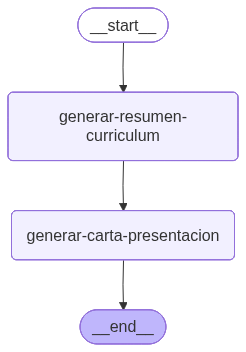

In [14]:
from IPython.display import Image, display

# Generar y mostrar la visualización del flujo de trabajo.
display(Image(app.get_graph().draw_mermaid_png()))

Ahora estamos definiendo la entrada para el flujo de trabajo proporcionando una descripción del trabajo y, a continuación, invocando la aplicación compilada con esta entrada para ejecutar todo el proceso de encadenamiento de solicitudes.

In [15]:
estado_entrada = {
        "descripcion_puesto": "Buscamos un científico de datos con experiencia en aprendizaje automático, procesamiento del lenguaje natural (PLN) y Python. Es imprescindible tener experiencia previa trabajando con grandes conjuntos de datos y en la implementación de modelos en producción."
}

resultado = app.invoke(estado_entrada)

In [16]:
resultado

{'descripcion_puesto': 'Buscamos un científico de datos con experiencia en aprendizaje automático, procesamiento del lenguaje natural (PLN) y Python. Es imprescindible tener experiencia previa trabajando con grandes conjuntos de datos y en la implementación de modelos en producción.',
 'resumen_perfil': '**Resumen de Currículum**\n\nCientífico de Datos con sólida experiencia en aprendizaje automático y procesamiento del lenguaje natural (PLN). Experto en Python con un historial demostrado en el manejo y análisis de grandes conjuntos de datos. Habilidad para implementar modelos en producción, optimizando su desempeño y garantizando su efectividad. Capaz de transformar datos complejos en soluciones comerciales innovadoras, contribuyendo al crecimiento y éxito de proyectos basados en datos.',
 'carta_presentacion': '[Tu Nombre]  \n[Tu Dirección]  \n[Tu Ciudad, Estado, Código Postal]  \n[Tu Correo Electrónico]  \n[Tu Teléfono]  \n[Fecha]  \n\n[Nombre del Reclutador]  \n[Nombre de la Empres

## 5. Patrón de Flujo de Trabajo: Enrutamiento

### *5.1. Patrón de Flujo de Trabajo: Enrutamiento*

El enrutamiento es un patrón en el que un LLM (o agente de enrutamiento pequeño) **clasifica o interpreta la entrada** y luego **la dirige al subproceso** o agente apropiado. Este diseño es útil cuando se trabaja con **múltiples tipos de tareas o intenciones de usuario** y se requiere lógica o manejo especializado para cada caso.

Funciona como una centralita: un nodo inteligente (un clasificador o enrutador) analiza la entrada y la dirige a la rama correcta.

### *5.2. Casos de Uso*

- Bots de atención al cliente con IA (para facturación, soporte técnico o consultas generales)

- Agentes multihabilidad (por ejemplo, resumen, traducción y extracción de datos)

- Bots educativos adaptativos (para acceder a módulos de matemáticas, ciencias o gramática)

### *5.3. Técnicas de Enrutamiento*

1. **Enrutamiento basado en palabras clave codificadas** (primitivo)

2. **Enrutamiento basado en LLM** mediante indicaciones de clasificación

3. **Coincidencia semántica basada en incrustaciones** con un mapa de enrutamiento

### *5.4. Caso de uso: Enrutamiento — Clasificador de Tareas para Resumen y Traducción*

En este flujo de trabajo, construiremos un **enrutador de tareas** sencillo utilizando el patrón de diseño de enrutamiento. El objetivo es crear un sistema que pueda decidir de forma inteligente si el usuario desea **resumir** o **traducir** una entrada determinada, y luego enviarla a la ruta de procesamiento adecuada.

Este patrón es útil cuando el sistema necesita gestionar **varios tipos de tareas** según la intención del usuario. En lugar de crear un modelo grande para gestionarlo todo, permitimos que un **nodo enrutador** clasifique la solicitud y la dirija a un **subproceso especializado**.

Por ejemplo:
- Si la entrada es «Resumir este artículo sobre IA», el enrutador la envía al **resumidor**.

- Si la entrada es «Traducir esto al francés», la envía al **traductor**.

Ahora definimos el `EstadoEnrutador` usando `TypedDict` para representar el estado compartido en nuestro flujo de trabajo de enrutamiento. Este estado incluye:

- `entrada_usuario`: la entrada sin procesar proporcionada por el usuario.

- `tipo_tarea`: el tipo de tarea determinado por el enrutador (por ejemplo, "resumir" o "traducir").

- `salida`: el resultado final generado después de enrutar al controlador de tareas correspondiente.

In [47]:
class EstadoEnrutador(TypedDict):
    entrada_usuario: str
    tipo_tarea: str
    salida: str

Ahora definimos el `nodo-enrutador`, que actúa como el responsable de la toma de decisiones en el flujo de trabajo. Envía una solicitud al LLM para que clasifique la intención del usuario como "resumir" o "traducir". El resultado se almacena en el campo `tipo_tarea` del estado y determinará a qué nodo de procesamiento se dirige el flujo de trabajo a continuación.

In [48]:
class Enrutador(BaseModel):
    rol: str = Field(..., description= "Decida si el usuario desea 'resumir' un pasaje o 'traducir' el texto al francés.")

llm_router = llm.bind_tools([Enrutador])

In [ ]:
respuesta = llm_router.invoke("resume esto me encanta el sol, hace mucho calor")

In [50]:
respuesta

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 74, 'total_tokens': 91, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_203cacd279', 'id': 'chatcmpl-DrSG9faTyTKx2C2EKlpybDFRA7J0M', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019ed190-bcad-70a3-97e5-d68a5b7b3419-0', tool_calls=[{'name': 'Enrutador', 'args': {'rol': 'resumir'}, 'id': 'call_YzWrH3y1fTT10bTKMFT1sFMU', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 74, 'output_tokens': 17, 'total_tokens': 91, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [73]:
def nodo_enrutador(estado: EstadoEnrutador) -> EstadoEnrutador:
    prompt_enrutador = f"""
    Eres un clasificador de tareas de IA.
    
    Decidir si el usuario desea:
    - "resumir" un pasaje
    - o "traducir" el texto al francés
    
    Responda con una sola palabra: “resumir” o “traducir”.
    
    Entrada del usuario: "{estado['entrada_usuario']}"
    """

    respuesta = llm_router.invoke(prompt_enrutador)

    return {**estado, "tipo_tarea": respuesta.tool_calls[0]['args']['rol']} # ¡Este se convierte en el nombre del siguiente nodo!

Ahora estamos definiendo la función `enrutador`, que simplemente devuelve el `tipo_tarea` del estado. LangGraph utilizará este valor para decidir a qué nodo enrutar a continuación según el resultado de la clasificación.


In [74]:
def enrutador(estado: EstadoEnrutador) -> str:
    return estado['tipo_tarea']

Ahora definimos el nodo `nodo-resumir`, que se encarga de resumir la entrada del usuario. Este nodo le indica al LLM que genere un resumen conciso y almacena el resultado en el campo `salida`, al tiempo que confirma que el tipo de tarea es "summarizar".

In [75]:
def nodo_resumir(estado: EstadoEnrutador) -> EstadoEnrutador:
    prompt = f"Por favor, resuma el siguiente pasaje:\n\n{estado['entrada_usuario']}"
    respuesta = llm.invoke(prompt)
    
    return {**estado, "tipo_tarea": "resumir", "salida": respuesta.content}

Ahora estamos definiendo el `nodo-traducir`, que gestiona las tareas de traducción. Este nodo le indica al LLM que traduzca la entrada del usuario al francés y guarda el texto traducido en el campo `salida`, al tiempo que actualiza el `tipo_tarea` a "traducir".

In [76]:
def nodo_traducir(estado: EstadoEnrutador) -> EstadoEnrutador:
    prompt = f"Traduzca el siguiente texto al francés:\n\n{estado['entrada_usuario']}"
    response = llm.invoke(prompt)

    return {**estado, "tipo_tarea": "traducir", "salida": response.content}

Ahora inicializamos un nuevo `StateGraph` utilizando el tipo `EstadoEnrutador`. Esto establece la estructura de nuestro flujo de trabajo de enrutamiento y define el esquema para el estado que se transmitirá entre los nodos.

In [77]:
flujo_trabajo = StateGraph(EstadoEnrutador)

Ahora añadimos tres nodos al flujo de trabajo:

- `"nodo-enrutador"`: El nodo que clasifica la entrada del usuario.

- `"nodo-resumir"`: El nodo que gestiona el resumen.

- `"nodo-traducir"`: El nodo que gestiona la traducción.

In [78]:
flujo_trabajo.add_node("nodo-enrutador", nodo_enrutador)
flujo_trabajo.add_node("nodo-resumir", nodo_resumir)
flujo_trabajo.add_node("nodo-traducir", nodo_traducir)

Ahora estamos configurando "nodo-enrutador" como punto de entrada del flujo de trabajo, lo que significa que la ejecución comenzará clasificando la intención del usuario.

In [79]:
flujo_trabajo.set_entry_point("nodo-enrutador")

Ahora agregamos aristas condicionales desde el nodo "enrutador" en función del valor devuelto por la función "enrutador". Si la tarea es "resumir", el flujo de trabajo se dirige al nodo "resumir"; si es "traducir", se dirige al nodo "traducir".

In [80]:
flujo_trabajo.add_conditional_edges("nodo-enrutador", enrutador, {
    "resumir": "nodo-resumir",
    "traducir": "nodo-traducir"
})

Ahora marcamos tanto "resumir" como "traducir" como puntos de finalización válidos. Esto significa que el flujo de trabajo puede terminar después de ejecutar cualquiera de los dos nodos, dependiendo del tipo de tarea seleccionado por el enrutador.

In [82]:
flujo_trabajo.set_finish_point("nodo-resumir")
flujo_trabajo.set_finish_point("nodo-traducir")

Compilamos el flujo de trabajo en una aplicación ejecutable mediante el método `compile()`. Este paso prepara los nodos definidos y la lógica de enrutamiento para que el flujo de trabajo pueda ejecutarse con datos de entrada reales.

In [83]:
app = flujo_trabajo.compile()

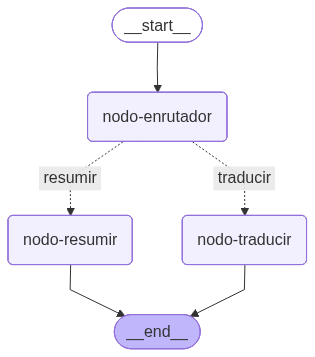

In [84]:
from IPython.display import Image, display

# Generar y mostrar la visualización del flujo de trabajo.
display(Image(app.get_graph().draw_mermaid_png()))

En este paso, proporcionamos una entrada mínima que contiene únicamente el campo `entrada_usuario`. Dado que el estado se define mediante `TypedDict`, los campos faltantes, como `tipo_tarea` y `salida`, se gestionarán automáticamente durante la ejecución. A continuación, invocamos la aplicación con esta entrada, lo que inicia el proceso de enrutamiento y ejecuta la tarea correspondiente según la intención del usuario.

In [85]:
entrada_texto = {
        "entrada_usuario": "¿Puedes traducir esta frase: Me encanta programar?"
    }

resultado = app.invoke(entrada_texto)

In [86]:
print(resultado['salida'])
print(resultado['tipo_tarea'])

Claro, la traducción al francés de "Me encanta programar" es "J'adore programmer".
traducir


Let's try the second task. 


In [88]:
entrada_texto = {
        "entrada_usuario": "¿Puedes resumir esta frase: Me encanta programar, es lo mejor del mundo. Lo único que quiero hacer es programar?"
    }

resultado = app.invoke(entrada_texto)

In [89]:
print(resultado['salida'])
print(resultado['tipo_tarea'])

La persona ama programar y desea dedicarse a ello por completo.
resumir


## 6. Patrón de Flujo de Trabajo: Paralelización

La paralelización es un patrón en el que **varias tareas de LLM se ejecutan simultáneamente** en lugar de una tras otra. Esto resulta útil cuando diferentes partes de la tarea pueden realizarse **de forma independiente**, lo que permite un procesamiento más rápido y un mejor rendimiento del sistema.

Imagínelo como una cocina donde un cocinero corta verduras, otro cuece pasta y otro hornea, todo al mismo tiempo. Ninguno tiene que esperar a que el otro termine.

En los flujos de trabajo de IA, esto significa dividir un problema en partes y ejecutarlas **en paralelo**, para luego recopilar y combinar los resultados.

### *6.1. Casos de Uso*

- Resumir simultáneamente diferentes secciones de un documento extenso.

- Traducir un lote de mensajes de usuario a la vez.

- Generar múltiples variaciones de un texto publicitario o descripción de producto.

- Realizar comprobaciones de seguridad utilizando diferentes indicaciones y comparar los resultados.

- Combinar resultados de diferentes modelos o indicaciones para alcanzar un consenso.

### *6.2. Técnicas de Paralelización*

1. **Diversidad de formatos (Tareas de múltiples salidas)**

- Ejecutar la misma entrada con diferentes estilos de indicaciones, idiomas o formatos de salida.

- Cada llamada al modelo LLM produce un resultado distinto en paralelo.

- Combinar todas las salidas en una respuesta unificada.

- *Ejemplo:* Traducir una oración al francés, español y japonés simultáneamente.

2. **División de tareas (Seccionado)**

- Dividir una entrada grande en partes más pequeñas.

- Ejecutar cada parte con la misma tarea (por ejemplo, resumen) en paralelo.

- Combinar los resultados parciales para obtener un resultado final.

- *Ejemplo:* Resumir cada párrafo de un artículo simultáneamente.

3. **Votación por consenso (Evaluación multiagente)**

- Ejecutar la misma tarea varias veces con diferentes agentes o estilos de indicaciones.

- Comparar las respuestas y elegir la mejor mediante clasificación o votación mayoritaria.

- *Ejemplo:* Solicitar a 3 variaciones de un modelo que escriban una respuesta segura y elegir la más apropiada.

### *6.3. ⚡ Caso de uso: Paralelización — Asistente de traducción multilingüe*

En este flujo de trabajo, estamos creando un **asistente de traducción multilingüe** utilizando el patrón de diseño de paralelización. El objetivo es tomar una sola oración en español y generar sus traducciones al **francés**, **inglés** y **japonés**, todo al mismo tiempo.

La paralelización es ideal para esta tarea porque las traducciones son **independientes entre sí**. Dado que cada traducción específica de un idioma se puede procesar por separado, podemos ejecutarlas en **paralelo** para ahorrar tiempo y mejorar la eficiencia.

Una vez completadas todas las traducciones, agregamos los resultados en un **único resultado multilingüe**, lo que facilita la presentación o el almacenamiento de todas las versiones juntas.

Para gestionar los datos que fluyen a través de nuestro flujo de trabajo de traducción paralela, definimos un `State` mediante `TypedDict`. Esta estructura nos permite realizar un seguimiento tanto de la entrada como de las salidas individuales de cada tarea paralela.

- `texto`: almacena la oración original en español que se va a traducir.

- `frances`: almacenará la traducción al francés.

- `ingles`: almacenará la traducción al inglés.

- `japones`: almacenará la traducción al japonés.

- `combinar_salidas`: almacenará el resultado final combinado de todas las traducciones.

In [137]:
class Estado(TypedDict):
    texto: str
    frances: str
    ingles: str
    japones: str
    combinar_salidas: str

Aquí definimos el nodo `traducir-frances`, que se encarga de traducir el texto de entrada al francés. Este nodo envía una solicitud al LLM pidiendo la versión en francés del texto de entrada y, a continuación, almacena el resultado en el campo `frances` del estado.

In [138]:
def traducir_frances(estado: Estado) -> Estado:
    resultado = llm.invoke(f"Traduzca el siguiente texto al francés:\n\n{estado['texto']}")
    return {"frances": resultado.content.strip()}

De la misma forma, definimos el nodo `traducir-ingles` para gestionar la traducción al español. Este nodo introduce el texto de entrada en el LLM y almacena el resultado traducido en el campo `ingles` del estado.

In [139]:
def traducir_ingles(estado: Estado) -> Estado:
    resultado = llm.invoke(f"Traduzca el siguiente texto al inglés:\n\n{estado['texto']}")
    return {"ingles": resultado.content.strip()}

De forma similar, crearemos un nodo `traducir-japones` para traducir el texto de entrada al japonés y almacenar el resultado en el campo `japones`.

In [140]:
def traducir_japones(estado: Estado) -> Estado:
    resultado = llm.invoke(f"Traduzca el siguiente texto al japonés:\n\n{estado['texto']}")
    return {"japones": resultado.content.strip()}

El nodo `agregador` se encarga de combinar las salidas de los tres nodos de traducción en un único formato legible. Construye una cadena formateada que incluye el texto original junto con sus traducciones al francés, español y japonés, y almacena el resultado final en el campo `salida_combinada`.

In [141]:
def agregador(estado: Estado) -> Estado:
    combinado = f"Texto original: {estado['texto']}\n\n"
    combinado += f"Francés: {estado['frances']}\n\n"
    combinado += f"Inglés: {estado['ingles']}\n\n"
    combinado += f"Japonés: {estado['japones']}\n"
    return {**estado, "combinar_salidas": combinado}

Inicializamos un nuevo `StateGraph` utilizando el tipo `Estado`. Esto sienta las bases para nuestro flujo de trabajo paralelo y define la estructura de los datos que fluirán entre los nodos.

In [142]:
grafo = StateGraph(Estado)

Añadimos cuatro nodos al grafo:

- `"traducir_frances"`: gestiona la traducción al francés,

- `"traducir_ingles"`: gestiona la traducción al inglés,

- `"traducir_japones"`: gestiona la traducción al japonés,

- `"agregador"`: recopila y combina todas las traducciones en un único resultado.

Cada uno de estos nodos funcionará de forma independiente antes de fusionarse en el agregador.

In [143]:
grafo.add_node("nodo-traducir-frances", traducir_frances)
grafo.add_node("nodo-traducir-ingles", traducir_ingles)
grafo.add_node("nodo-traducir-japones", traducir_japones)
grafo.add_node("nodo-agregador", agregador)

Conectamos los tres nodos de traducción al inicio del flujo de trabajo. Esto significa que todas las tareas de traducción comenzarán simultáneamente y en paralelo en cuanto se active el flujo de trabajo.

In [144]:
# Conectar nodos paralelos desde START.
grafo.add_edge(START, "nodo-traducir-frances")
grafo.add_edge(START, "nodo-traducir-ingles")
grafo.add_edge(START, "nodo-traducir-japones")

Aquí, conectamos cada uno de los nodos de traducción al nodo agregador. Una vez que todas las traducciones estén completas, sus resultados se enviarán al agregador para combinarlos en el resultado final.

In [145]:
# Conectar todos los nodos de traducción al agregador.
grafo.add_edge("nodo-traducir-frances", "nodo-agregador")
grafo.add_edge("nodo-traducir-ingles", "nodo-agregador")
grafo.add_edge("nodo-traducir-japones", "nodo-agregador")

Conectamos el nodo `agregador` al `END` del flujo de trabajo, marcándolo como el paso final donde se devuelve el resultado combinado.

In [146]:
# Nodo final.
grafo.add_edge("nodo-agregador", END)

In [147]:
# Compilar el grafo en una aplicación ejecutable.
app = grafo.compile()

Introducimos una frase en inglés en el campo `texto` e iniciamos el flujo de trabajo. Esto activa todas las tareas de traducción en paralelo y, una vez completadas, las traducciones se combinan y se devuelven como resultado final.

In [148]:
texto_entrada = {
        "texto": "¡Buenos días! Espero que tengas un día maravilloso."
}

resultado = app.invoke(texto_entrada)

In [149]:
resultado

{'texto': '¡Buenos días! Espero que tengas un día maravilloso.',
 'frances': "¡Buenos días! Espero que tengas un día maravilloso.  \n**Bonjour ! J'espère que tu auras une merveilleuse journée.**",
 'ingles': 'Good morning! I hope you have a wonderful day.',
 'japones': '¡Claro! Aquí tienes la traducción al japonés:\n\nおはようございます！素晴らしい一日をお過ごしください。',
 'combinar_salidas': "Texto original: ¡Buenos días! Espero que tengas un día maravilloso.\n\nFrancés: ¡Buenos días! Espero que tengas un día maravilloso.  \n**Bonjour ! J'espère que tu auras une merveilleuse journée.**\n\nInglés: Good morning! I hope you have a wonderful day.\n\nJaponés: ¡Claro! Aquí tienes la traducción al japonés:\n\nおはようございます！素晴らしい一日をお過ごしください。\n"}

## 7. Ejercicios: Creación de un Sistema de Enrutamiento Multiagente

### *7.1. Ejercicio 1 - Creación de una Herramienta de Gestión de Estado y Enrutamiento*

Defina la estructura de estado y la herramienta de clasificación para su sistema de enrutamiento multiagente. Deberá crear un diccionario tipado para la gestión de estado y un modelo Pydantic para la vinculación con la herramienta LLM.

Su tarea: Crear los componentes básicos para el enrutamiento entre servicios de transporte, pedidos de restaurantes, compras de supermercado y gestión de rutas predeterminadas.

In [151]:
class EstadoEnrutador(TypedDict):
    entrada_usuario: str
    tipo_tarea: str
    salida: str

class Enrutador(BaseModel):
    rol: str = Field(
        ..., 
        description= "Clasifique la solicitud del usuario. Devuelva exactamente uno de los siguientes: 'servicio_transporte', 'pedidos_restaurante', 'comestibles' y, si no lo sabe, devuelva 'predeterminado'."
    )

llm_router = llm.bind_tools([Enrutador])

### *7.2. Ejercicio 2 - Implementar la Lógica del Enrutador*

Crea la función del nodo del enrutador que clasifica la entrada del usuario y gestiona los casos en los que el LLM no devuelve una llamada a la herramienta. Implementa también la función de decisión del enrutador.

Tu tarea: Desarrolla la lógica de clasificación con el manejo de errores adecuado para las solicitudes no clasificadas.

In [152]:
def nodo_enrutador(estado: EstadoEnrutador) -> EstadoEnrutador:
    resupuesta = llm_router.invoke(estado['entrada_usuario'])
    
    if resupuesta.tool_calls:
        tool_call = resupuesta.tool_calls[0]['args']['rol']
        return {**estado, "tipo_tarea": tool_call}
    else:
        return {**estado, "tipo_tarea": "predeterminado"}

def enrutador(estado: EstadoEnrutador) -> str:
    return estado['tipo_tarea']

In [156]:
def nodo_servicio_transporte(estado: EstadoEnrutador) -> EstadoEnrutador:
    """
    Procesa las solicitudes de transporte extrayendo las ubicaciones de recogida/entrega y las preferencias.
    """
    prompt = f"""
    Eres asistente de transporte. Según la solicitud del usuario, extrae y organiza la siguiente información:

    - Lugar de recogida
    - Lugar de destino/entrega
    - Tipo de viaje preferido (si se especifica)
    - Requisitos especiales
    - Preferencias de tiempo estimado

    Solicitud del usuario: "{estado['entrada_usuario']}"
    
    Proporcione un resumen claro de la solicitud de viaje con todos los detalles disponibles.
    """
    
    respuesta = llm.invoke(prompt)
    
    return {
        **estado, 
        "tipo_tarea": "servicio_transporte", 
        "salida": respuesta.content.strip()
    }

def nodo_restaurante_pedido(estado: EstadoEnrutador) -> EstadoEnrutador:
    """
    Procesa los pedidos del restaurante organizando los artículos del menú, las cantidades y las preferencias.
    """
    prompt = f"""
    Eres un asistente de pedidos de restaurante. Según la solicitud del usuario, organiza la siguiente información:

    - Artículos del menú solicitados
    - Cantidades para cada artículo
    - Modificaciones especiales o restricciones dietéticas
    - Preferencia de entrega o recogida
    - Cualquier requisito de tiempo o instrucciones adicionales

    Solicitud del usuario: "{estado['entrada_usuario']}"
    
    Proporcione un resumen claro y organizado del pedido del restaurante con todos los detalles.
    """
    
    respuesta = llm.invoke(prompt)
    
    return {
        **estado, 
        "tipo_tarea": "pedidos_restaurante", 
        "salida": respuesta.content.strip()
    }

def nodo_comestibles(estado: EstadoEnrutador) -> EstadoEnrutador:
    """
    Gestiona las solicitudes de entrega de comestibles con servicio de recogida por parte del conductor.
    """
    prompt = f"""
    Eres asistente de reparto de comestibles para un servicio donde nuestros repartidores recogen las compras de los clientes.

    Según la solicitud del usuario, organiza la siguiente información:

    Lista de la compra:
    - Lista de productos necesarios
    - Cantidades de cada producto
    - Marcas preferidas (si se mencionan)
    - Restricciones dietéticas o preferencias por productos orgánicos

    Información de la tienda:
    - Tienda o ubicación preferida
    - Presupuesto
    - Instrucciones especiales para encontrar los productos

    Detalles de la entrega:
    - Dirección de entrega (si se proporciona)
    - Franja horaria de entrega preferida
    - Instrucciones especiales de entrega
    - Información de contacto para coordinar con el repartidor

    Instrucciones para el repartidor:
    - Preferencias de sustitución (si el producto no está disponible)
    - Cómo gestionar los productos agotados
    - Productos que requieren manipulación especial (frágiles, refrigerados)
    - Método de pago (si se menciona)
    
    Solicitud del usuario: "{estado['entrada_usuario']}"
    
    Proporcione un resumen completo de su pedido de entrega para que nuestro conductor pueda comprar y entregar los productos de manera eficiente.
    Incluya la hora estimada de recogida y cualquier nota especial para la compra.

    Formatee la respuesta como un pedido de entrega claro y organizado que incluya todos los detalles necesarios para nuestro servicio de entrega.
    """
    
    respuesta = llm.invoke(prompt)
    
    return {
        **estado, 
        "tipo_tarea": "comestibles", 
        "salida": respuesta.content.strip()
    }
def nodo_predeterminado(estado: EstadoEnrutador) -> EstadoEnrutador:
    prompt = f"""
    No pude clasificar su solicitud en una categoría específica.
    Permítame brindarle asistencia general para: "{estado['entrada_usuario']}"
    
    Puedo ayudarte con:
    - Servicios de transporte compartido
    - Pedidos en restaurantes
    - Compras de supermercado

    Por favor, reformula tu solicitud para que se ajuste a uno de estos servicios. Si necesitas ayuda con otra cosa, te pondré en contacto con nuestro equipo de atención al cliente, que te brindará asistencia personalizada.

    ¿Te gustaría que:
    1. Te ayude a reformular tu solicitud para uno de nuestros servicios?
    2. Te ponga en contacto con atención al cliente para obtener ayuda adicional?
    """

    respuesta = llm.invoke(prompt)

    return {**estado, "tipo_tarea": "predeterminado", "salida": respuesta.content.strip()}


### *7.3. Ejercicio 3 - Ensamblar el Flujo de Trabajo Completo*

Ensambla todas las piezas construyendo el gráfico de estados, agregando nodos, configurando la lógica de enrutamiento y compilando la aplicación.

Tu tarea: Crea el gráfico de flujo de trabajo completo con el enrutamiento y los puntos de finalización adecuados, y llámalo `app`.

In [157]:
flujo_trabajo = StateGraph(EstadoEnrutador)

# Agregar todos los nodos al flujo de trabajo.
flujo_trabajo.add_node("nodo-enrutador", nodo_enrutador)
flujo_trabajo.add_node("nodo-servicio-transporte", nodo_servicio_transporte)
flujo_trabajo.add_node("nodo-restaurante-pedido", nodo_restaurante_pedido)
flujo_trabajo.add_node("nodo-comestibles", nodo_comestibles)
flujo_trabajo.add_node("nodo-predeterminado", nodo_predeterminado)

# Establecer el nodo de enrutamiento como punto de entrada.
flujo_trabajo.set_entry_point("nodo-enrutador")

# Agregar nodo condicional para enrutar a los nodos correspondientes según la clasificación del enrutador.
flujo_trabajo.add_conditional_edges("nodo-enrutador", enrutador, {
    "comestibles": "nodo-comestibles", 
    "pedidos_restaurante": "nodo-restaurante-pedido",
    "servicio_transporte": "nodo-servicio-transporte",
    "predeterminado": "nodo-predeterminado"
})

# Establecer los nodos de servicio como puntos de finalización.
flujo_trabajo.set_finish_point("nodo-servicio-transporte")
flujo_trabajo.set_finish_point("nodo-restaurante-pedido")
flujo_trabajo.set_finish_point("nodo-comestibles")
flujo_trabajo.set_finish_point("nodo-predeterminado")

# Compilar el flujo de trabajo en una aplicación ejecutable.
app = flujo_trabajo.compile()

Implementación del Testeo

In [158]:
casos_test = [
    {"entrada_usuario": "Necesito que me lleven del centro al aeropuerto a las 3 de la tarde."},
    {"entrada_usuario": "Quiero pedir 2 pizzas grandes de pepperoni para entrega"},
    {"entrada_usuario": "Necesito leche, pan, huevos y verduras para la semana"},
    {"entrada_usuario": "¿Cómo está el clima hoy?"},  # Prueba de caso predeterminado/no clasificado.
]

for i, test_input in enumerate(casos_test, 1):
    resultado = app.invoke(test_input)


    print(f"Pregunta {test_input["entrada_usuario"]}\n")
    print(f"tipo de tarea {resultado['tipo_tarea']}\n")
    print(f"salida: {resultado['salida']}\n")
    print('-----------------------------------')

Pregunta Necesito que me lleven del centro al aeropuerto a las 3 de la tarde.

tipo de tarea servicio_transporte

salida: Aquí tienes el resumen de la solicitud de viaje:

- **Lugar de recogida**: Centro
- **Lugar de destino/entrega**: Aeropuerto
- **Tipo de viaje preferido**: No especificado
- **Requisitos especiales**: Ninguno mencionado
- **Preferencias de tiempo estimado**: A las 3 de la tarde

Si necesitas más información o detalles adicionales, házmelo saber.

-----------------------------------
Pregunta Quiero pedir 2 pizzas grandes de pepperoni para entrega

tipo de tarea pedidos_restaurante

salida: **Resumen del Pedido del Restaurante:**

- **Artículos del menú solicitados:**
  - 2 pizzas grandes de pepperoni

- **Cantidades:**
  - Pizzas grandes de pepperoni: 2

- **Modificaciones especiales o restricciones dietéticas:**
  - No se mencionaron modificaciones especiales ni restricciones dietéticas.

- **Preferencia de entrega o recogida:**
  - Entrega

- **Cualquier requisito 

Copyright © IBM Corporation. All rights reserved (Español).